# Main Fig 3 — Iso-compute Heatmap

**Data**: `heatmap_df_test.csv`  
**Tasks (main)**: 4 representative tasks — sex, apnea, sleep efficiency, BMI  
**Head**: Transformer  
**Layout**: 2 rows × 2 cols (2×2 grid, FULL_W wide)  

Four tasks chosen to illustrate the four distinct iso-compute regimes:  
- **(a) sex_binary** — long-$L$ dominates at high budget ($\geq$240 min)  
- **(b) apnea_binary** — moderate $L{=}80$ min optimal; neither extreme wins  
- **(c) sleep_efficiency_binary** — short-context ceiling ($\approx$0.707), long $L$ needed  
- **(d) bmi_binary** — context-insensitive null case (near-flat across all budgets)  

Age-group (same long-$L$ pattern as sex) moved to supplementary.  
For all tasks see the commented supplementary block at the end.


In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [4]:
HEAD   = "transformer"
METRIC = "auroc"
ROW_H  = 2.0   # inches per row

# ── Main figure: 4 tasks showing distinct iso-compute regimes ───────────────
# (a) sex_binary:               long-L dominates at high budgets (≥240 min)
# (b) apnea_binary:             moderate context optimal (L=80m, K=3 at 240-min budget)
# (c) sleep_efficiency_binary:  short-context ceiling (~0.707); long context needed
# (d) bmi_binary:               context-insensitive null case (near-flat everywhere)
TASKS = ["sex_binary", "apnea_binary", "sleep_efficiency_binary", "bmi_binary"]

hmaps = {t: load_heatmap("phase0_v3", t, HEAD) for t in TASKS}
print("Loaded:", {t: len(v) for t, v in hmaps.items()})


Loaded: {'sex_binary': 76, 'apnea_binary': 81, 'sleep_efficiency_binary': 85, 'bmi_binary': 81}


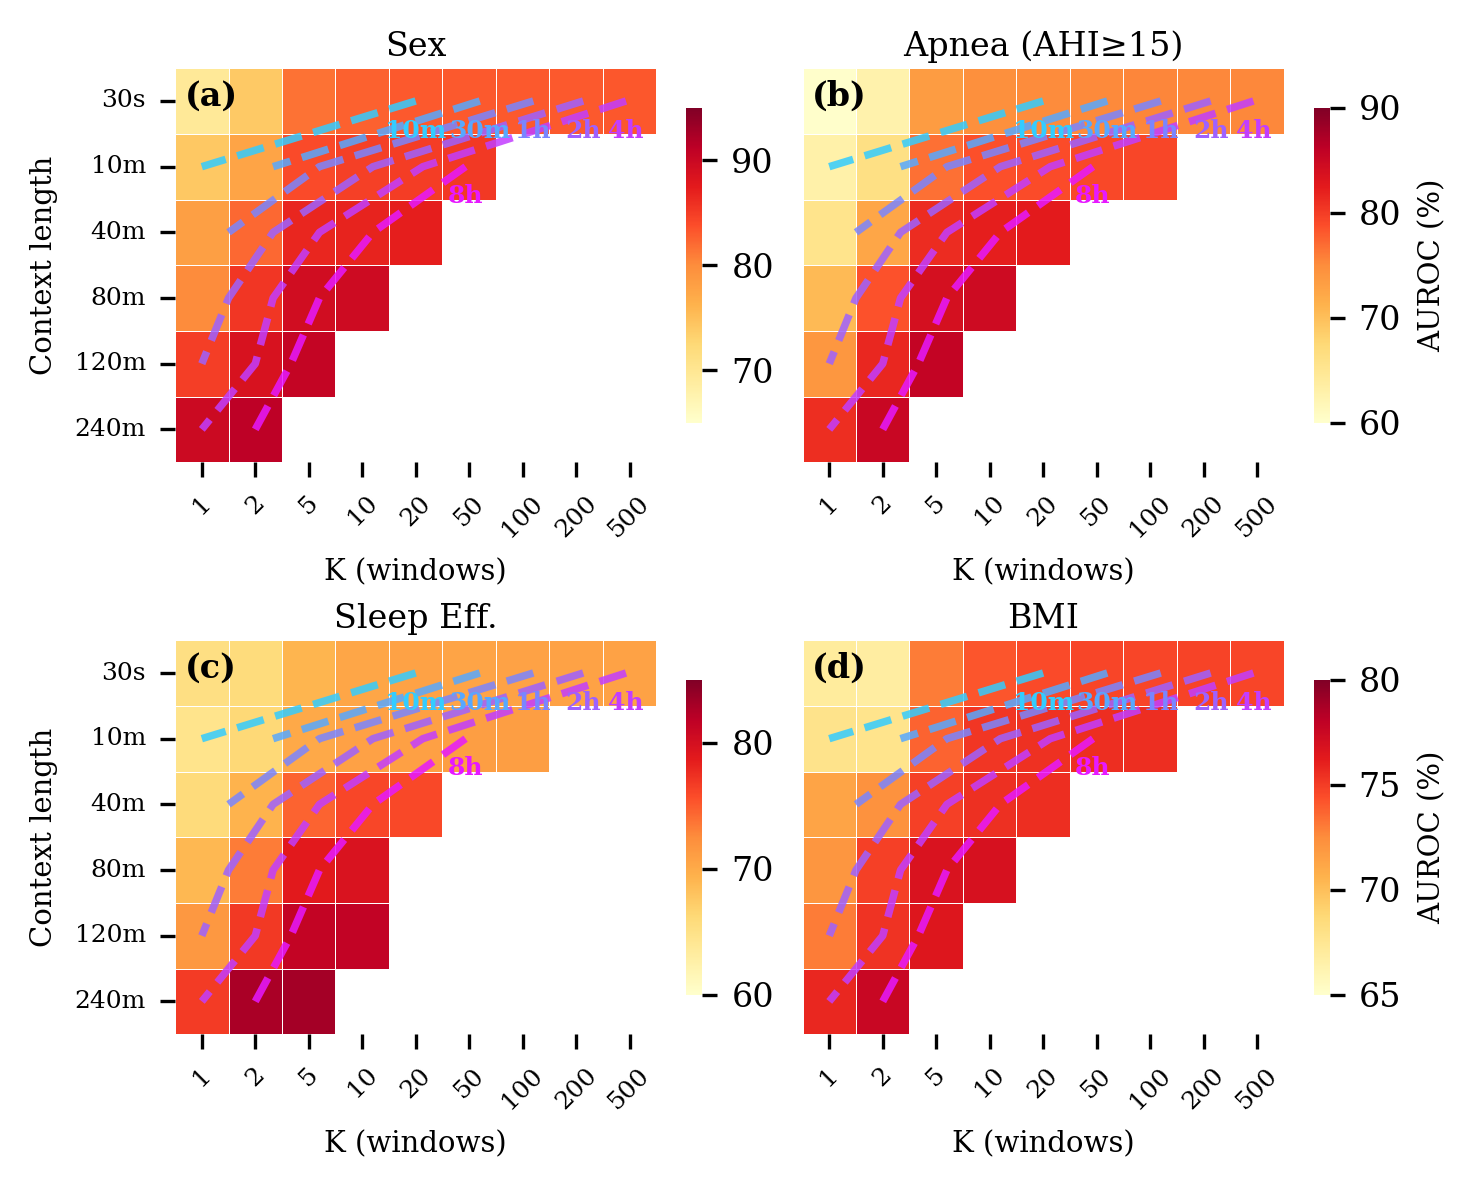

In [14]:
# 2×2 grid — each row has a left panel (y-labels on, cbar unlabelled)
# and a right panel (y-labels off, cbar labelled "AUROC (%)").
fig, axes = plt.subplots(2, 2, figsize=(FULL_W-2, 2 * ROW_H))
axes_flat = axes.flatten()

# (show_ylabels, show_cbar_label)
panel_flags = [
    (True,  False),   # (a) sex            top-left
    (False, True),    # (b) apnea          top-right
    (True,  False),   # (c) sleep_eff      bottom-left
    (False, True),    # (d) bmi            bottom-right
]

for i, (ax, task) in enumerate(zip(axes_flat, TASKS)):
    show_y, show_cbar_lbl = panel_flags[i]
    panels.heatmap_panel(ax, hmaps[task], col=METRIC,
                         show_ylabels=show_y, show_cbar_label=show_cbar_lbl)
    ax.set_title(TASK_LABEL[task], fontsize=8, pad=3)
    add_panel_label(ax, f"({chr(97+i)})")

fig.tight_layout(h_pad=0.5, w_pad=0.5)
plt.show()


In [ ]:
# ── Run when figure looks good ──────────────────────────────────
save_figure(fig, FINAL_OUT, "main_fig3_heatmap")
print("Saved →", FINAL_OUT / "main_fig3_heatmap.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/main_fig3_heatmap.pdf
Saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/main_fig3_heatmap.pdf


## ── SUPPLEMENTARY VERSION ─────────────────────────────────────────────────────

**Target:** `sfig_heatmap.pdf`  
**→ also copy to:** `npj_digital_medicine_submission/sfig_heatmap.pdf`  

Shows the iso-compute heatmap for the **remaining tasks** not shown in the main figure:  
- **(a) age_class** — same long-$L$ dominance as sex (moves to supp to avoid redundancy)  
- **(b) depression_extreme_binary** — supplementary task  
- **(c) osa_binary_apples_postqc** — supplementary task (APPLES dataset only)  

> **Pattern for all main figures:** every main figure notebook ends with a block  
> like this. Uncomment → run → the supplementary PDF updates automatically.


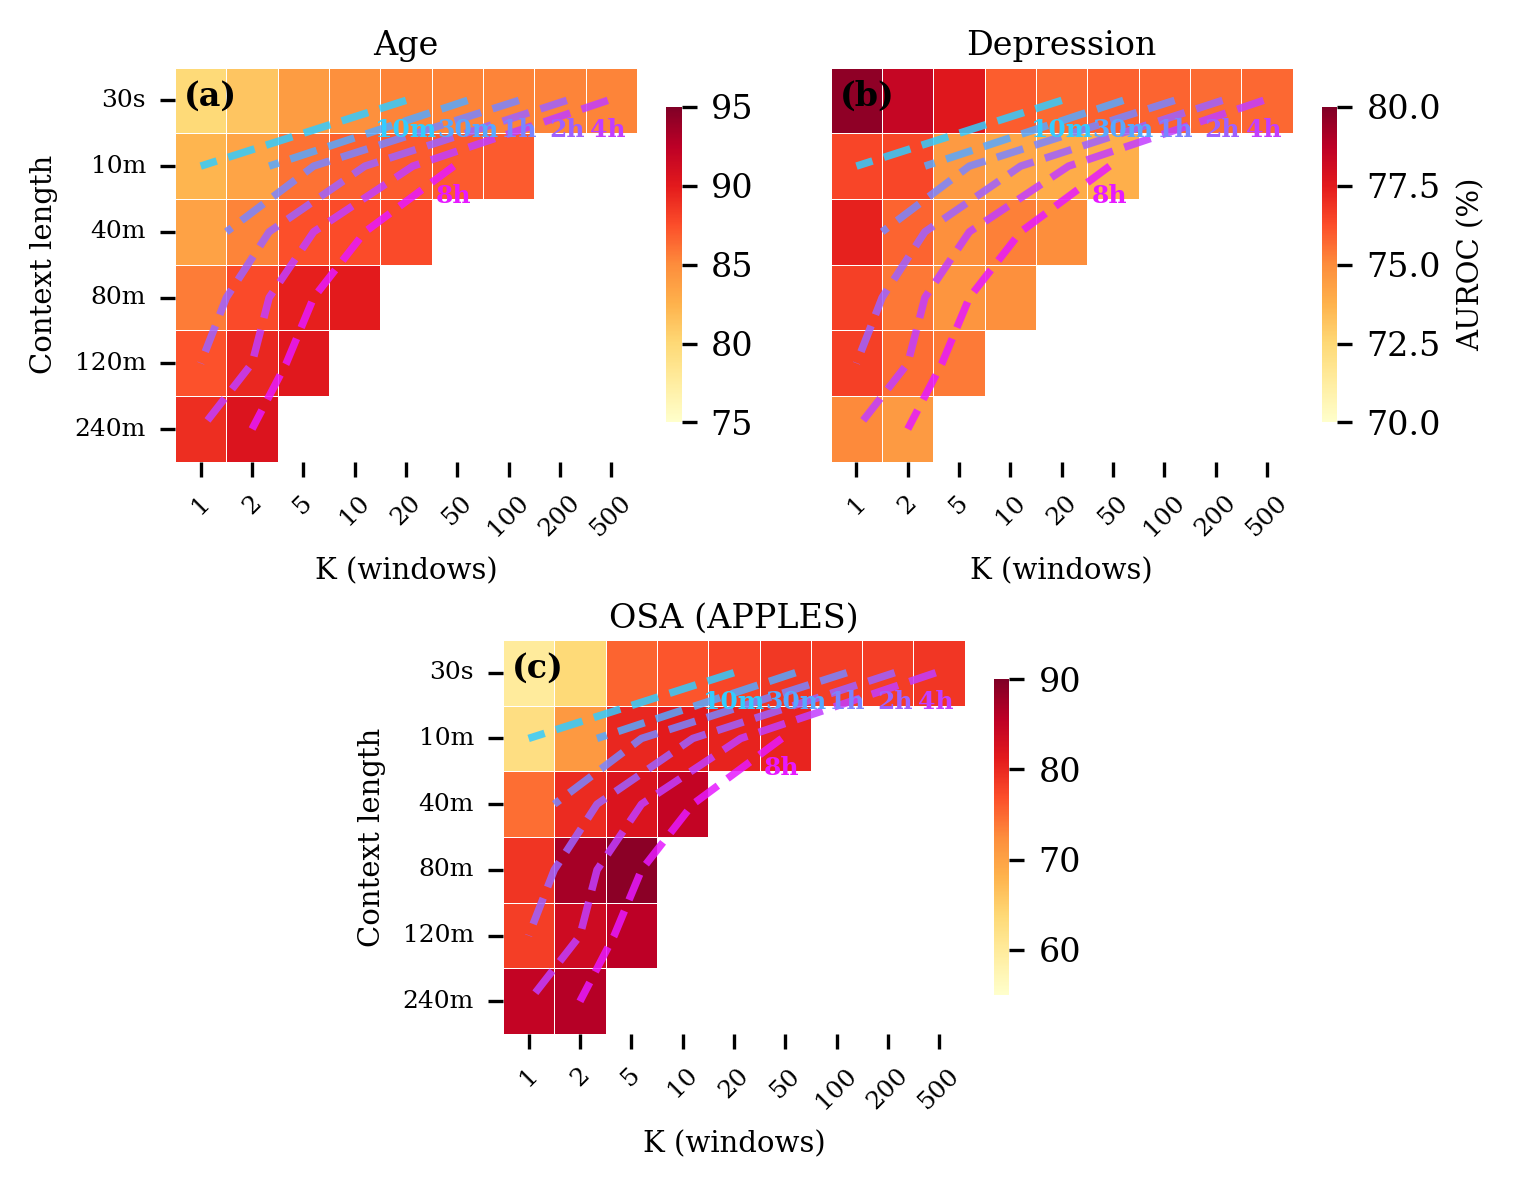

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SUPPLEMENTARY  sfig_heatmap — iso-compute heatmap, remaining tasks
# Target: sfig_heatmap.pdf  (copy to npj_digital_medicine_submission/ when done)
# To regenerate: uncomment ALL lines below, then run this cell.
# ══════════════════════════════════════════════════════════════════════════════

_SUPP_TASKS_H = [
    "age_class",               # same pattern as sex; moved here to avoid redundancy
    "depression_extreme_binary",
    "osa_binary_apples_postqc",
    # "cvd_binary",            # exclude for now — add back when results are ready
]
_SUPP_NCOLS  = 2
_SUPP_ROW_H  = 2.0
_SUPP_NROWS  = (len(_SUPP_TASKS_H) + _SUPP_NCOLS - 1) // _SUPP_NCOLS

_supp_hmaps = {t: load_heatmap('phase0_v3', t, HEAD) for t in _SUPP_TASKS_H}

# 2+1 centred mosaic (same pattern as fig2 supp)
_sl = [chr(97 + _i) for _i in range(len(_SUPP_TASKS_H))]
_n_last = len(_SUPP_TASKS_H) % _SUPP_NCOLS or _SUPP_NCOLS
_n_full  = len(_SUPP_TASKS_H) // _SUPP_NCOLS
_mosaic  = []
for _r in range(_n_full):
    _row = _sl[_r * _SUPP_NCOLS : (_r + 1) * _SUPP_NCOLS]
    _mosaic.append([lbl for lbl in _row for _ in range(2)])
if _n_last < _SUPP_NCOLS:
    _last = _sl[_n_full * _SUPP_NCOLS:]
    _pad  = _SUPP_NCOLS - _n_last
    _mosaic.append(['.'] * _pad +
                   [lbl for lbl in _last for _ in range(2)] +
                   ['.'] * _pad)

fig_supp, axd_supp = plt.subplot_mosaic(
    _mosaic, figsize=(FULL_W-2, _SUPP_NROWS * _SUPP_ROW_H)
)
# Left col: y-labels on, cbar unlabelled; Right col: y-labels off, cbar labelled
_supp_flags = [(True, False), (False, True), (True, False)]
for _i, (_lbl, _task) in enumerate(zip(_sl, _SUPP_TASKS_H)):
    _sy, _sc = _supp_flags[_i]
    panels.heatmap_panel(axd_supp[_lbl], _supp_hmaps[_task], col=METRIC,
                         show_ylabels=_sy, show_cbar_label=_sc)
    axd_supp[_lbl].set_title(TASK_LABEL[_task], fontsize=8, pad=3)
    add_panel_label(axd_supp[_lbl], f'({chr(97+_i)})')
fig_supp.tight_layout(h_pad=0.5, w_pad=-2.0)
plt.show()


In [ ]:
# Save and copy to npj_digital_medicine_submission
save_figure(fig_supp, FINAL_OUT, 'sfig_heatmap')
import shutil
_submission = WORKSPACE_ROOT / 'npj_digital_medicine_submission'
shutil.copy(FINAL_OUT / 'sfig_heatmap.pdf',
            _submission / 'sfig_heatmap.pdf')
print('Saved + copied → npj_digital_medicine_submission/sfig_heatmap.pdf')


  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig_heatmap.pdf
Saved + copied → TBME_submission/sfig_heatmap.pdf
